# Tanimoto GRPO: Top Unique Molecules

Load generated samples, score final valid RL molecules by Morgan Tanimoto similarity to Prilocaine, deduplicate by heavy-atom canonical SMILES, and plot Prilocaine plus the top 10 unique hits.

Generate samples first from the repository root:

```bash
python -m rl.experiments.tanimoto.generate_tanimoto_grpo_samples --n_mols 300
```

Override `SAMPLES_PT` below if you save the artifact somewhere else.

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import pandas as pd
import torch
from IPython.display import display
from rdkit import Chem
from rdkit.Chem import DataStructs, Draw

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if not (ROOT / "pyproject.toml").exists():
    ROOT = Path(os.environ.get("PROJECT_ROOT", ".")).resolve()
os.environ.setdefault("PROJECT_ROOT", str(ROOT))
for p in (ROOT, ROOT / "src"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from rl.rewards import _SHAPE_REF_SMILES, _get_tanimoto_ref, _heavy_atom_mol

RL_STEM = "grpo_tanimoto_seed0_sig0p05_g8_mu2_kl0.02_lr1e-4_continue_maxa100-omitposkl_scaff_b10_p0p5_w50_canonsmi_best"
SAMPLES_PT = ROOT / "rl" / "experiments" / "tanimoto" / RL_STEM / "tanimoto_grpo_samples.pt"
SAMPLES_PT

PosixPath('/network/scratch/g/goldszaa/chemflow/rl/experiments/tanimoto/grpo_tanimoto_seed0_sig0p05_g8_mu2_kl0.02_lr1e-4_continue_maxa100-omitposkl_scaff_b10_p0p5_w50_canonsmi_best/tanimoto_grpo_samples.pt')

In [2]:
blob = torch.load(SAMPLES_PT, map_location="cpu", weights_only=False)
vocab = blob["vocab"]
atom_tokens = vocab["atom_tokens"]
edge_tokens = vocab["edge_tokens"]
charge_tokens = vocab["charge_tokens"]

print("loaded:", SAMPLES_PT)
print("meta:", blob.get("meta", {}))
print("base valid:", len(blob["base"].get("valid_mols", [])))
print("rl valid:", len(blob["rl"].get("valid_mols", [])))

/home/mila/g/goldszaa/scratch/chemflow/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loaded: /network/scratch/g/goldszaa/chemflow/rl/experiments/tanimoto/grpo_tanimoto_seed0_sig0p05_g8_mu2_kl0.02_lr1e-4_continue_maxa100-omitposkl_scaff_b10_p0p5_w50_canonsmi_best/tanimoto_grpo_samples.pt
meta: {'pretrained_ckpt': '/network/scratch/g/goldszaa/chemflow/.pretrained_model/epoch=499-step=48500.ckpt', 'rl_ckpt': '/network/scratch/g/goldszaa/chemflow/.rl_ckpts/grpo_tanimoto_seed0_sig0p05_g8_mu2_kl0.02_lr1e-4_continue_maxa100-omitposkl_scaff_b10_p0p5_w50_canonsmi_best.pt', 'n_mols_requested': 300, 'integrator_max_atoms': 100, 'hydra_overrides': ['data.datamodule.batch_size.test=128']}
base valid: 300
rl valid: 300


In [3]:
ref = _get_tanimoto_ref()
ref_mol = Chem.MolFromSmiles(_SHAPE_REF_SMILES)
ref_heavy = _heavy_atom_mol(ref_mol)

def final_rdkit(traj):
    return traj[-1].to_rdkit_mol(atom_tokens, edge_tokens, charge_tokens)

def score_rdkit(rd):
    heavy = _heavy_atom_mol(rd)
    fp = ref["morgan_gen"].GetFingerprint(heavy)
    return float(DataStructs.TanimotoSimilarity(fp, ref["fp"]))

def canonical_heavy_smiles(rd):
    return Chem.MolToSmiles(_heavy_atom_mol(rd), canonical=True)

rows = []
for idx, traj in enumerate(blob["rl"].get("valid_mols", [])):
    rd = final_rdkit(traj)
    if rd is None:
        continue
    try:
        heavy_smi = canonical_heavy_smiles(rd)
        explicit_smi = Chem.MolToSmiles(rd, canonical=True)
        rows.append({
            "idx": idx,
            "tanimoto": score_rdkit(rd),
            "heavy_smiles": heavy_smi,
            "explicit_smiles": explicit_smi,
            "n_atoms": int(rd.GetNumAtoms()),
            "mol": rd,
        })
    except Exception as exc:
        print(f"skip idx={idx}: {exc}")

if not rows:
    raise RuntimeError("No valid RL molecules could be converted/scored from this artifact.")

df_all = pd.DataFrame(rows)
df_unique = (
    df_all.sort_values("tanimoto", ascending=False)
    .drop_duplicates("heavy_smiles", keep="first")
    .reset_index(drop=True)
)
top10 = df_unique.head(10).copy()
display(df_unique[["idx", "tanimoto", "n_atoms", "heavy_smiles"]].head(20))
print(f"scored={len(df_all)} unique={len(df_unique)}")

,idx,tanimoto,n_atoms,heavy_smiles
0,70,0.432432,24,CCCNC(C)C(C)=O
1,195,0.341463,27,CCCNC(C)CC(C)=O
2,158,0.333333,24,CCCNC(=O)C(C)C
3,233,0.325000,22,CCCNC(=O)C(C)O
4,238,0.317073,27,CCCNC(=O)C(C)CC
5,107,0.300000,24,CCNC(C)C(=O)CC
6,56,0.275000,31,CCCNC(CC)C(C)C
7,5,0.261905,23,CCNC(=O)C(C)NC
8,180,0.250000,21,CCCNC(=O)CC
9,53,0.250000,21,CCNC(=O)C(C)C


scored=300 unique=263


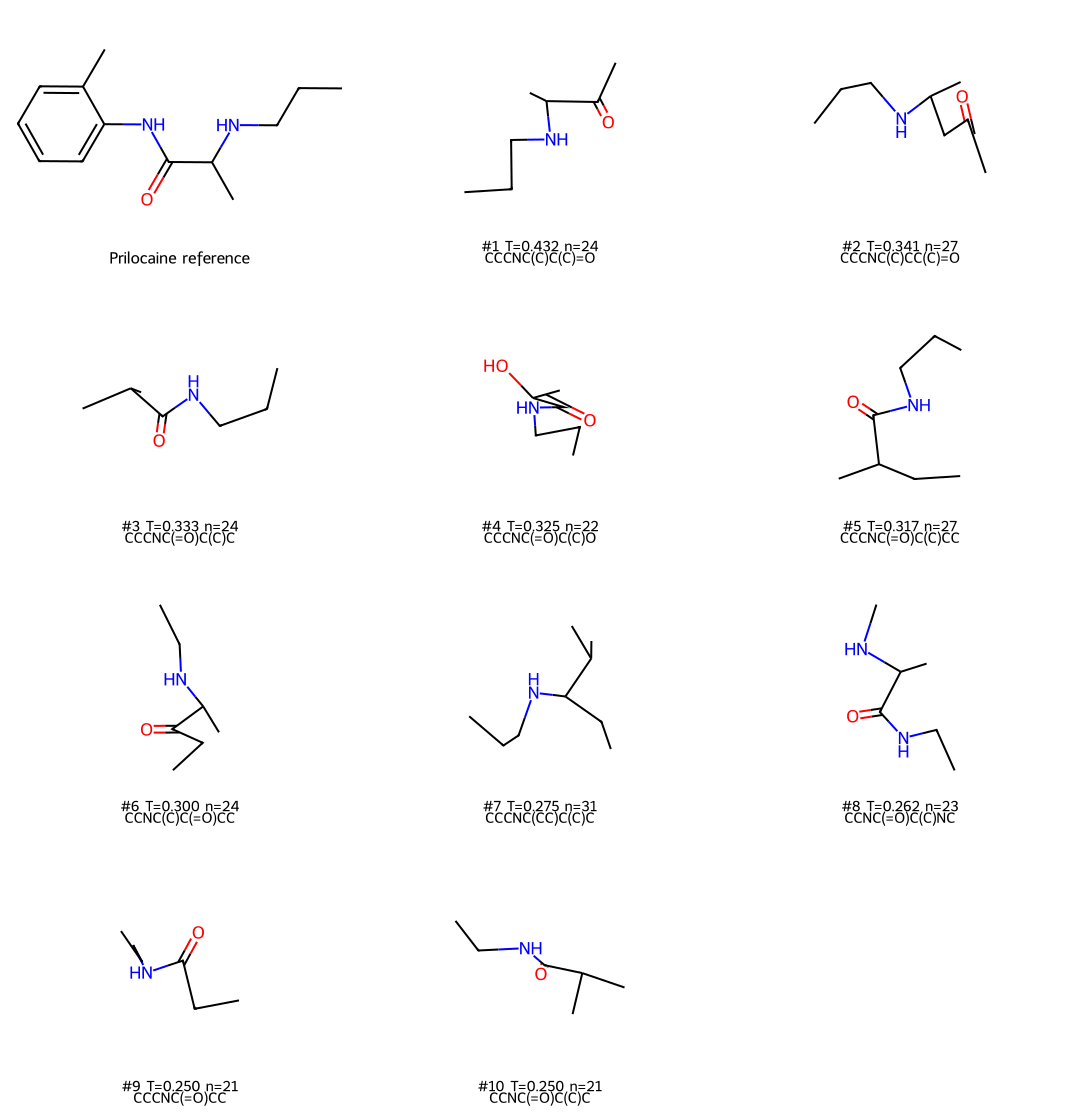

In [4]:
mols = [ref_heavy] + [_heavy_atom_mol(row["mol"]) for _, row in top10.iterrows()]
legends = ["Prilocaine reference"]
for rank, (_, row) in enumerate(top10.iterrows(), start=1):
    legends.append(f"#{rank} T={row['tanimoto']:.3f} n={row['n_atoms']}\n{row['heavy_smiles']}")

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=3,
    subImgSize=(360, 280),
    legends=legends,
    useSVG=True,
)
display(img)

In [5]:
out_csv = SAMPLES_PT.with_name("top10_tanimoto_unique.csv")
top10.drop(columns=["mol"]).to_csv(out_csv, index=False)
print("saved:", out_csv)

saved: /network/scratch/g/goldszaa/chemflow/rl/experiments/tanimoto/grpo_tanimoto_seed0_sig0p05_g8_mu2_kl0.02_lr1e-4_continue_maxa100-omitposkl_scaff_b10_p0p5_w50_canonsmi_best/top10_tanimoto_unique.csv


## Aromatic ring analysis

RL valid molecules with aromatic rings: 20/300 (6.7%)
unique aromatic molecules: 20/263


,idx,tanimoto,n_atoms,num_aromatic_rings,heavy_smiles
0,174,0.219512,17,1,Cc1cccc(O)c1O
1,208,0.209302,18,1,Cc1cccc(O)c1N
2,217,0.205128,21,1,CC(C)c1ccccc1
3,169,0.205128,18,1,CCc1ccccc1
4,252,0.195652,22,1,CCC(C)c1ccc[nH]1
5,109,0.173913,21,1,CCNc1c[nH]c(C)c1
6,221,0.166667,24,1,CCNc1cc[nH]c1CC
7,240,0.163265,22,1,CCc1oc(NC)cc1N
8,114,0.162791,17,1,Cc1cccc(=O)cc1
9,59,0.160000,22,1,CCNc1cc(CO)c[nH]1


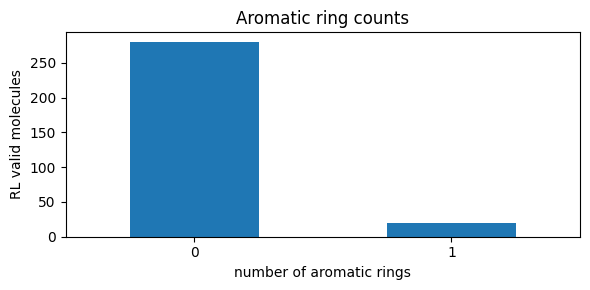

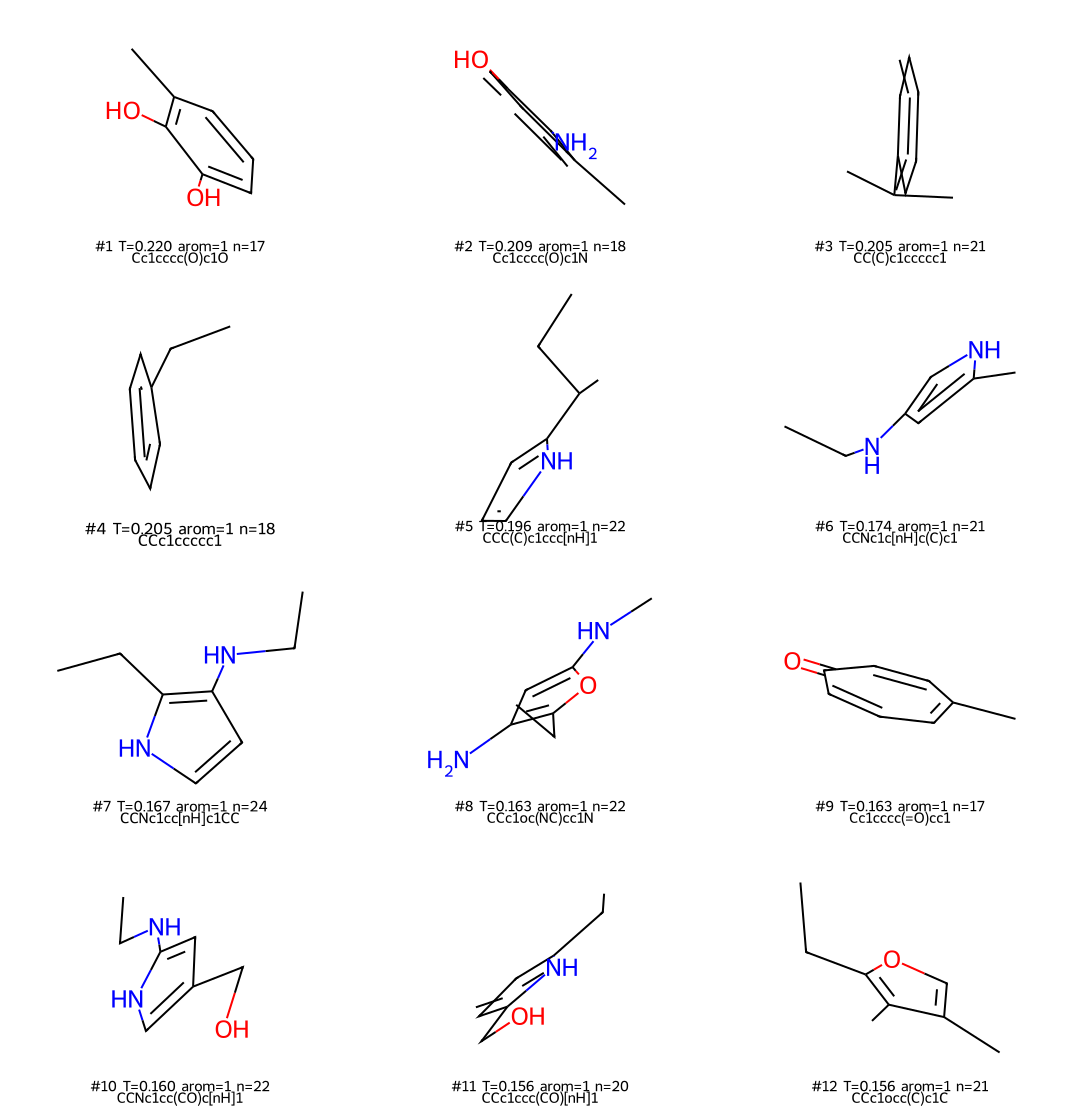

In [6]:
import matplotlib.pyplot as plt
from rdkit.Chem import rdMolDescriptors

def num_aromatic_rings(rd):
    return int(rdMolDescriptors.CalcNumAromaticRings(_heavy_atom_mol(rd)))

df_all["num_aromatic_rings"] = df_all["mol"].map(num_aromatic_rings)
df_aromatic_all = (
    df_all[df_all["num_aromatic_rings"] > 0]
    .sort_values("tanimoto", ascending=False)
    .reset_index(drop=True)
)
df_aromatic_unique = (
    df_aromatic_all.drop_duplicates("heavy_smiles", keep="first")
    .reset_index(drop=True)
)

n_aromatic = len(df_aromatic_all)
pct_aromatic = 100.0 * n_aromatic / len(df_all)
print(f"RL valid molecules with aromatic rings: {n_aromatic}/{len(df_all)} ({pct_aromatic:.1f}%)")
print(f"unique aromatic molecules: {len(df_aromatic_unique)}/{df_all['heavy_smiles'].nunique()}")

display(df_aromatic_all[["idx", "tanimoto", "n_atoms", "num_aromatic_rings", "heavy_smiles"]])

ring_counts = df_all["num_aromatic_rings"].value_counts().sort_index()
ax = ring_counts.plot.bar(figsize=(6, 3), rot=0)
ax.set_xlabel("number of aromatic rings")
ax.set_ylabel("RL valid molecules")
ax.set_title("Aromatic ring counts")
plt.tight_layout()
plt.show()

ring_top = df_aromatic_unique.head(12)
if len(ring_top) == 0:
    print("No aromatic-ring molecules found in the RL valid set.")
else:
    ring_mols = [_heavy_atom_mol(row["mol"]) for _, row in ring_top.iterrows()]
    ring_legends = [
        f"#{rank} T={row['tanimoto']:.3f} arom={row['num_aromatic_rings']} n={row['n_atoms']}\n{row['heavy_smiles']}"
        for rank, (_, row) in enumerate(ring_top.iterrows(), start=1)
    ]
    display(Draw.MolsToGridImage(
        ring_mols,
        molsPerRow=3,
        subImgSize=(360, 280),
        legends=ring_legends,
        useSVG=True,
    ))